1. Importing Necessary Libraries

In [1]:
# General
import os
import datetime
import re
from time import time
from tqdm import tqdm
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline

# OpenCV
import cv2

2. Load Data

In [2]:
# dataset path
DATA_PATH = "../../datasets/lisa-traffic-light-dataset"
os.listdir(DATA_PATH)

['Annotations',
 'daySequence1',
 'daySequence2',
 'dayTrain',
 'nightSequence1',
 'nightSequence2',
 'nightTrain',
 'sample-dayClip6',
 'sample-nightClip1']

In [3]:
# day annotations path
DAY_TRAIN_PATH = '../../datasets/lisa-traffic-light-dataset/Annotations/Annotations/dayTrain'
os.listdir(DAY_TRAIN_PATH)

['dayClip1',
 'dayClip10',
 'dayClip11',
 'dayClip12',
 'dayClip13',
 'dayClip2',
 'dayClip3',
 'dayClip4',
 'dayClip5',
 'dayClip6',
 'dayClip7',
 'dayClip8',
 'dayClip9']

In [4]:
# night annotations path
NIGHT_TRAIN_PATH = '../../datasets/lisa-traffic-light-dataset/Annotations/Annotations/nightTrain'
os.listdir(NIGHT_TRAIN_PATH)

['nightClip1', 'nightClip2', 'nightClip3', 'nightClip4', 'nightClip5']

Merge all different Annotation Files into a single file

"isNight" feature will be used to split the data so that there will be balance between Day & Night Clips in Train & Test sets

In [5]:
# Loads and merges data from CSV files containing annotations (e.g., bounding boxes)
# for day and night videos, and adds a flag indicating whether each record is day or night.

train_day = []
for clipName in tqdm(sorted(os.listdir(DAY_TRAIN_PATH))):
    if 'dayClip' not in clipName:
        continue
    df = pd.read_csv(os.path.join(DAY_TRAIN_PATH,clipName,'frameAnnotationsBOX.csv'),sep=';')
    train_day.append(df)
    
train_day_df = pd.concat(train_day,axis=0)
train_day_df['isNight'] = 0

train_night = []
for clipName in tqdm(sorted(os.listdir(NIGHT_TRAIN_PATH))):
    if 'nightClip' not in clipName:
        continue
    df = pd.read_csv(os.path.join(NIGHT_TRAIN_PATH,clipName,'frameAnnotationsBOX.csv'),sep=';')
    train_night.append(df)

train_night_df = pd.concat(train_night,axis=0)
train_night_df['isNight'] = 1

# Iterates through all folders inside DAY_TRAIN_PATH.
# Keeps only those whose name contains 'dayClip'.
# Reads the 'frameAnnotationsBOX.csv' file for each folder (semicolon-delimited).
# Concatenates all day data into a single DataFrame.
# Adds column isNight = 0 to mark day samples.

# Same logic for night data.
# Sets isNight = 1 to distinguish night samples from day.

df = pd.concat([train_day_df,train_night_df],axis=0)

# Concatenates day and night data into a single unified DataFrame.

100%|██████████| 5/5 [00:00<00:00, 156.25it/s]


In [6]:
# Merged annotations shape: (rows, cols)
df.shape

(51826, 11)

In [7]:
# Preview first 5 rows
df.head()

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin file,Origin frame number,Origin track,Origin track frame number,isNight
0,dayTraining/dayClip1--00000.jpg,go,698,333,710,358,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,0,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,0,0
1,dayTraining/dayClip1--00000.jpg,go,846,391,858,411,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,0,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,0,0
2,dayTraining/dayClip1--00001.jpg,go,698,337,710,357,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,1,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,1,0
3,dayTraining/dayClip1--00001.jpg,go,847,390,859,410,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,1,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,1,0
4,dayTraining/dayClip1--00002.jpg,go,698,331,710,356,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,2,dayTraining/dayClip1/dayClip1Shutter0.000800-G...,2,0


3. Data Preprocessing

In [8]:
# Check if column pairs are identical across all rows -> (bool, bool)
np.all(df['Origin file'] == df['Origin track']), np.all(df['Origin frame number'] == df['Origin track frame number'])

(True, True)

In [9]:
# Droppin duplicate columns & "Origin file" as we don't need it
df = df.drop(['Origin file','Origin track','Origin track frame number'],axis=1)

In [10]:
# Preview first 5 rows
df.head()

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin frame number,isNight
0,dayTraining/dayClip1--00000.jpg,go,698,333,710,358,0,0
1,dayTraining/dayClip1--00000.jpg,go,846,391,858,411,0,0
2,dayTraining/dayClip1--00001.jpg,go,698,337,710,357,1,0
3,dayTraining/dayClip1--00001.jpg,go,847,390,859,410,1,0
4,dayTraining/dayClip1--00002.jpg,go,698,331,710,356,2,0


In [11]:
# Fix 'Filename' to the correct image path based on day/night.
# Example:
#   'dayTraining/dayClip1--00000.jpg'
#   -> '<DATA_PATH>/dayTrain/dayTrain/dayClip1/frames/dayClip1--00000.jpg'

def changeFilename(x):
    filename = x.Filename   # original relative path, e.g., 'dayTraining/dayClip1--00000.jpg'
    isNight = x.isNight     # 1/True for night, 0/False for day
    
    splitted = filename.split('/')          # split path into components
    clipName = splitted[-1].split('--')[0]  # e.g., 'dayClip1' from 'dayClip1--00000.jpg'
    if isNight:
        # build night path (layout-specific; 'nightTrain/nightTrain' intentional)
        return os.path.join(DATA_PATH,f'nightTrain/nightTrain/{clipName}/frames/{splitted[-1]}')
    else:
        # build day path (layout-specific; 'dayTrain/dayTrain' intentional)
        return os.path.join(DATA_PATH,f'dayTrain/dayTrain/{clipName}/frames/{splitted[-1]}')

# Apply per row to rewrite the 'Filename' column
df['Filename'] = df.apply(changeFilename,axis=1)


In [12]:
# Preview first 5 rows
df.head()

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin frame number,isNight
0,../../datasets/lisa-traffic-light-dataset\dayT...,go,698,333,710,358,0,0
1,../../datasets/lisa-traffic-light-dataset\dayT...,go,846,391,858,411,0,0
2,../../datasets/lisa-traffic-light-dataset\dayT...,go,698,337,710,357,1,0
3,../../datasets/lisa-traffic-light-dataset\dayT...,go,847,390,859,410,1,0
4,../../datasets/lisa-traffic-light-dataset\dayT...,go,698,331,710,356,2,0


In [13]:
# Unique annotation labels (class names)
df['Annotation tag'].unique()

array(['go', 'stop', 'stopLeft', 'warning', 'goLeft', 'warningLeft'],
      dtype=object)

In [14]:
# Label distribution (counts per class)
df['Annotation tag'].value_counts()

Annotation tag
go             22946
stop           18382
stopLeft        7707
warning         1258
goLeft          1236
warningLeft      297
Name: count, dtype: int64

In [15]:
# Map annotation tags to 3 classes: go(1), warning(2), stop(3)
label_to_idx = {'go':1, 'warning':2, 'stop': 3}
idx_to_label = {v:k for k,v in label_to_idx.items()}

def changeAnnotation(x):
    # Return numeric label based on substring in 'Annotation tag'
    if 'go' in x['Annotation tag']:
        return label_to_idx['go']
    elif 'warning' in x['Annotation tag']:
        return label_to_idx['warning']
    elif 'stop' in x['Annotation tag']:
        return label_to_idx['stop']
    # If no match, this will return None 
    
df['Annotation tag'] = df.apply(changeAnnotation,axis=1)

# Sanity check: expected unique values -> [1, 2, 3]
annotation_tags = df['Annotation tag'].unique()
annotation_tags

array([1, 3, 2], dtype=int64)

In [16]:
# Preview first 5 rows
df.head()

,Filename,Annotation tag,Upper left corner X,Upper left corner Y,Lower right corner X,Lower right corner Y,Origin frame number,isNight
0,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,333,710,358,0,0
1,../../datasets/lisa-traffic-light-dataset\dayT...,1,846,391,858,411,0,0
2,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,337,710,357,1,0
3,../../datasets/lisa-traffic-light-dataset\dayT...,1,847,390,859,410,1,0
4,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,331,710,356,2,0


In [17]:
# Changing Column Names
df.columns = ['image_id','label','x_min','y_min','x_max','y_max','frame','isNight']

In [18]:
# Preview first 5 rows
df.head()

,image_id,label,x_min,y_min,x_max,y_max,frame,isNight
0,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,333,710,358,0,0
1,../../datasets/lisa-traffic-light-dataset\dayT...,1,846,391,858,411,0,0
2,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,337,710,357,1,0
3,../../datasets/lisa-traffic-light-dataset\dayT...,1,847,390,859,410,1,0
4,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,331,710,356,2,0


4. Exploratory Data Analysis

In [19]:
# Unique images vs total annotation rows
print("Number of Unique Images: ",df.image_id.nunique(),'/',df.shape[0])

Number of Unique Images:  18013 / 51826


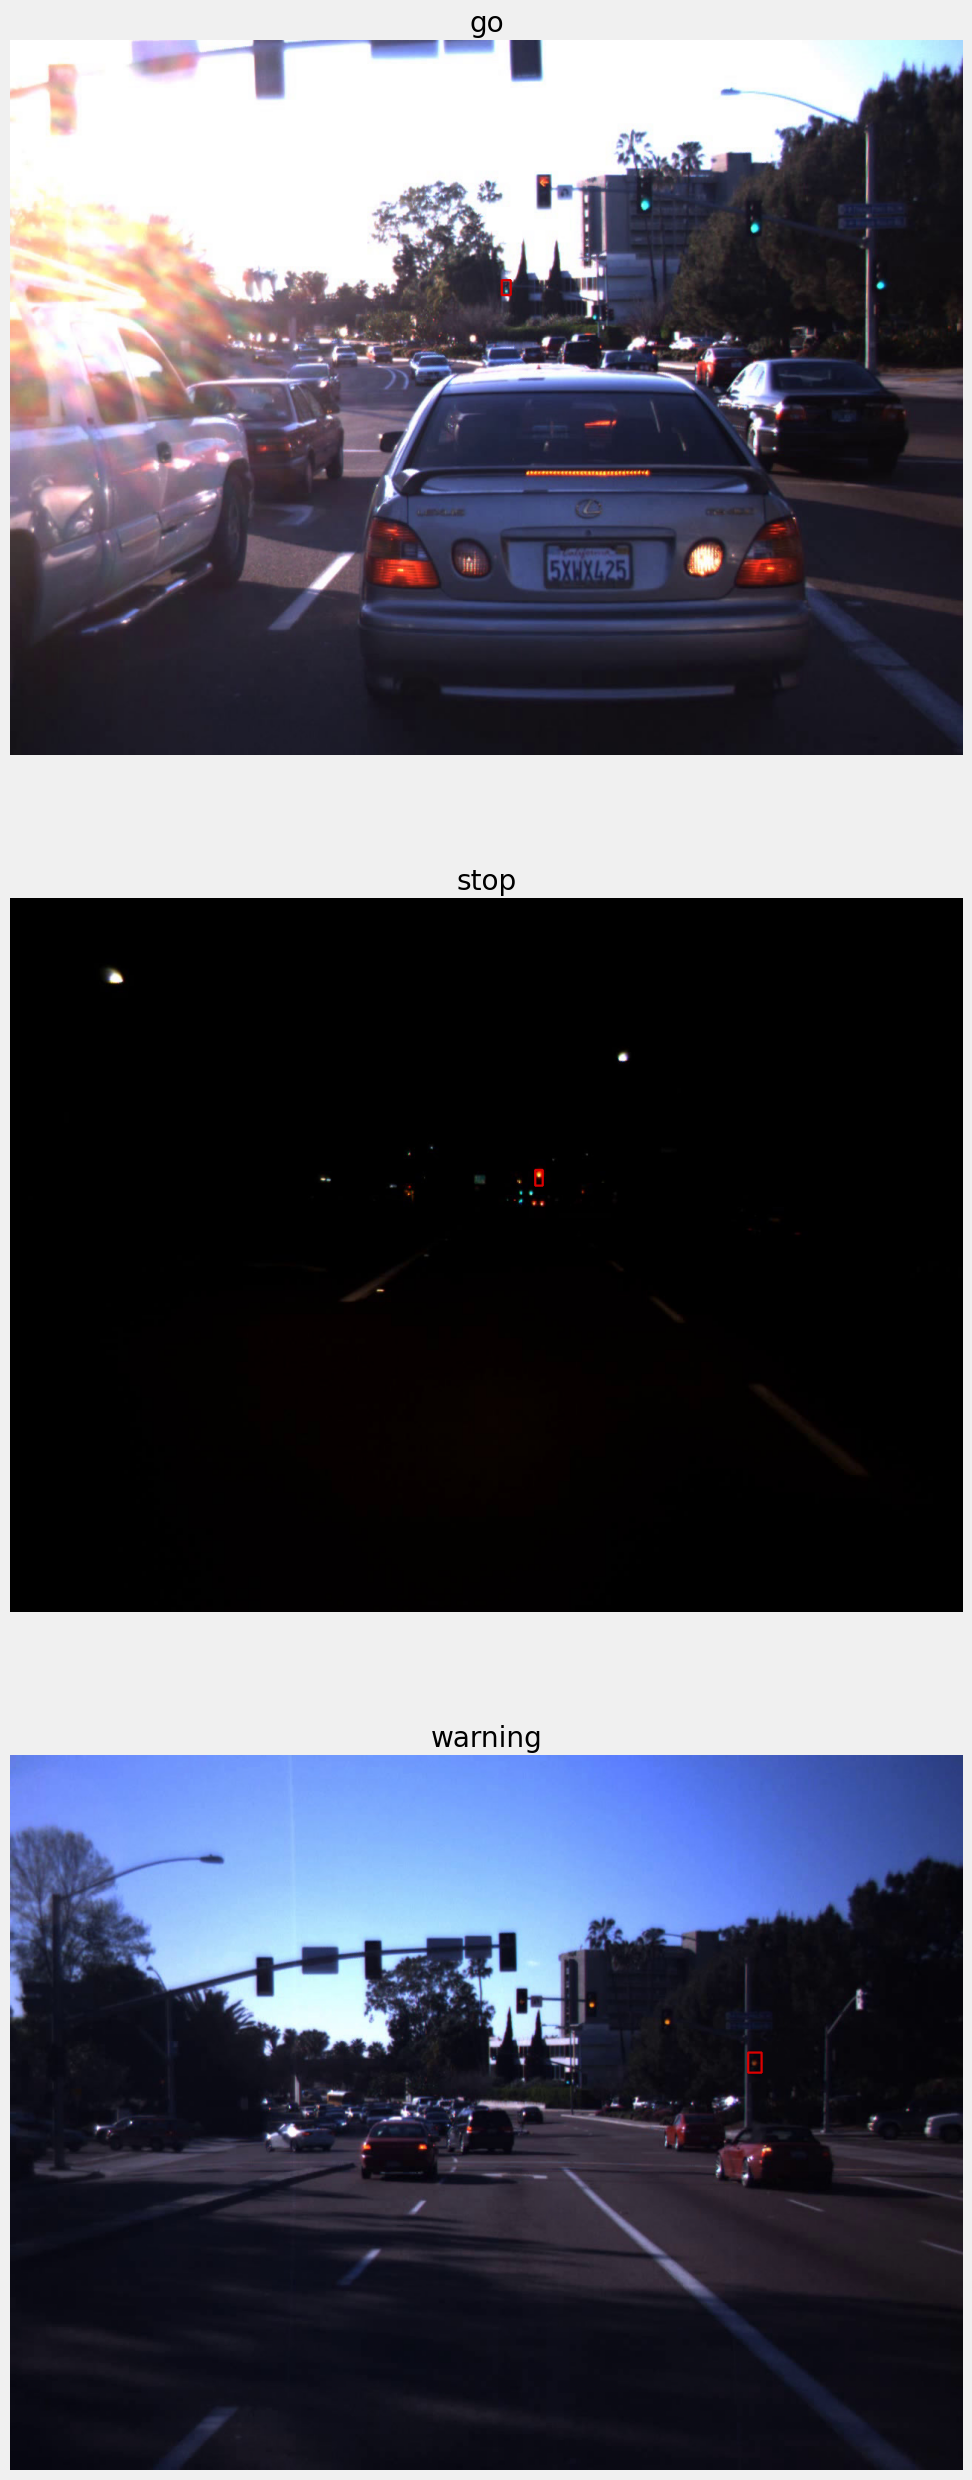

In [20]:
# Plot one random example (with bbox) per class in `annotation_tags`
fig, ax = plt.subplots(len(annotation_tags),1,figsize=(15,10*len(annotation_tags)))

for i, tag in enumerate(annotation_tags):
    # pick a random row for this class
    sample = df[df['label']==tag].sample(1)
    bbox = sample[['x_min','y_min','x_max','y_max']].values[0]
    
    # load and convert image for matplotlib
    image = cv2.imread(sample.image_id.values[0])
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    
    # draw bbox (ensure ints)
    cv2.rectangle(image,(bbox[0],bbox[1]),(bbox[2],bbox[3]),(220, 0, 0), 2)
    
     # title and render
    ax[i].set_title(idx_to_label[tag])
    ax[i].set_axis_off()
    ax[i].imshow(image)

5. Validation Scheme

As we have data from multiple clips, we will have to ensure that all the images from a same clip would either be in the train set or in test set. This will ensure that, there will not be any overlapping between the train & the test data.

In [21]:
# Extract clip name from image path (brittle: assumes fixed depth at index 5)
df['clipNames'] = df[['image_id']].applymap(lambda x: x.split('/')[5])

# Unique clip names
df['clipNames'].unique()

C:\Users\evri\AppData\Local\Temp\ipykernel_6984\27896815.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df['clipNames'] = df[['image_id']].applymap(lambda x: x.split('/')[5])


array(['dayClip1', 'dayClip10', 'dayClip11', 'dayClip12', 'dayClip13',
       'dayClip2', 'dayClip3', 'dayClip4', 'dayClip5', 'dayClip6',
       'dayClip7', 'dayClip8', 'dayClip9', 'nightClip1', 'nightClip2',
       'nightClip3', 'nightClip4', 'nightClip5'], dtype=object)

Train & Test Set split

In [22]:
def split(df,p=0.25):
    # Build clip name lists
    clipNames = sorted(df['clipNames'].unique())
    nightClips = [name for name in clipNames if 'night' in name]
    dayClips = [name for name in clipNames if 'day' in name]

    # Sample test clips per split 
    testNightClipNames = list(np.random.choice(nightClips,int(len(nightClips)*p)))
    testDayClipNames = list(np.random.choice(dayClips,int(len(dayClips)*p)))
    testClipNames = testNightClipNames + testDayClipNames

    # Train = remaining clips
    trainDayClipNames = list(set(dayClips) - set(testDayClipNames))
    trainNightClipNames = list(set(nightClips) - set(testNightClipNames))
    trainClipNames = trainNightClipNames + trainDayClipNames
    
    # Partition rows by clip
    train_df = df[df.clipNames.isin(trainClipNames)]
    test_df = df[df.clipNames.isin(testClipNames)]
    
    return train_df, test_df

In [23]:
# Clip-wise train/test split (≈25% test by default)
train_df, test_df = split(df)

In [24]:
# Preview first 5 rows
train_df.head()

,image_id,label,x_min,y_min,x_max,y_max,frame,isNight,clipNames
0,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,333,710,358,0,0,dayClip1
1,../../datasets/lisa-traffic-light-dataset\dayT...,1,846,391,858,411,0,0,dayClip1
2,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,337,710,357,1,0,dayClip1
3,../../datasets/lisa-traffic-light-dataset\dayT...,1,847,390,859,410,1,0,dayClip1
4,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,331,710,356,2,0,dayClip1


In [25]:
# Preview first 5 rows
test_df.head()

,image_id,label,x_min,y_min,x_max,y_max,frame,isNight,clipNames
0,../../datasets/lisa-traffic-light-dataset\dayT...,1,271,379,283,399,0,0,dayClip12
1,../../datasets/lisa-traffic-light-dataset\dayT...,1,610,294,625,314,0,0,dayClip12
2,../../datasets/lisa-traffic-light-dataset\dayT...,1,774,359,792,394,0,0,dayClip12
3,../../datasets/lisa-traffic-light-dataset\dayT...,1,266,364,284,404,1,0,dayClip12
4,../../datasets/lisa-traffic-light-dataset\dayT...,1,609,293,627,313,1,0,dayClip12


In [26]:
# Sanity check: dataset sizes after clip-wise split (rows, cols)
print("Train shape: ",train_df.shape)
print("Test shape: ",test_df.shape)

Train shape:  (37393, 9)
Test shape:  (14433, 9)


Train & Validation Split

We will do the similar thing that we did for the train-test-split above

In [27]:
# Clip-wise split of the training set to create a validation set (default 25%)
train_df, val_df = split(train_df)

# Preview first 5 rows
train_df.head()

,image_id,label,x_min,y_min,x_max,y_max,frame,isNight,clipNames
0,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,333,710,358,0,0,dayClip1
1,../../datasets/lisa-traffic-light-dataset\dayT...,1,846,391,858,411,0,0,dayClip1
2,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,337,710,357,1,0,dayClip1
3,../../datasets/lisa-traffic-light-dataset\dayT...,1,847,390,859,410,1,0,dayClip1
4,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,331,710,356,2,0,dayClip1


In [28]:
# Preview first 5 rows
val_df.head()

,image_id,label,x_min,y_min,x_max,y_max,frame,isNight,clipNames
0,../../datasets/lisa-traffic-light-dataset\dayT...,3,902,242,929,287,0,0,dayClip2
1,../../datasets/lisa-traffic-light-dataset\dayT...,3,1220,334,1244,374,0,0,dayClip2
2,../../datasets/lisa-traffic-light-dataset\dayT...,3,754,243,784,288,0,0,dayClip2
3,../../datasets/lisa-traffic-light-dataset\dayT...,3,174,351,192,378,0,0,dayClip2
4,../../datasets/lisa-traffic-light-dataset\dayT...,3,902,240,929,289,1,0,dayClip2


In [29]:
# Sanity check: dataset sizes after clip-wise split (rows, cols)
print("Train shape: ",train_df.shape)
print("Validation shape: ",val_df.shape)

Train shape:  (30707, 9)
Validation shape:  (6686, 9)


In [30]:
# Tag each subset with its split label for downstream merges/exports
train_df['split'] = 'train'
val_df['split']   = 'val'
test_df['split']  = 'test'

C:\Users\evri\AppData\Local\Temp\ipykernel_6984\2856339507.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['split']  = 'test'


In [31]:
# Preview first 5 rows
train_df.head()

,image_id,label,x_min,y_min,x_max,y_max,frame,isNight,clipNames,split
0,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,333,710,358,0,0,dayClip1,train
1,../../datasets/lisa-traffic-light-dataset\dayT...,1,846,391,858,411,0,0,dayClip1,train
2,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,337,710,357,1,0,dayClip1,train
3,../../datasets/lisa-traffic-light-dataset\dayT...,1,847,390,859,410,1,0,dayClip1,train
4,../../datasets/lisa-traffic-light-dataset\dayT...,1,698,331,710,356,2,0,dayClip1,train


In [32]:
# Preview first 5 rows
test_df.head()

,image_id,label,x_min,y_min,x_max,y_max,frame,isNight,clipNames,split
0,../../datasets/lisa-traffic-light-dataset\dayT...,1,271,379,283,399,0,0,dayClip12,test
1,../../datasets/lisa-traffic-light-dataset\dayT...,1,610,294,625,314,0,0,dayClip12,test
2,../../datasets/lisa-traffic-light-dataset\dayT...,1,774,359,792,394,0,0,dayClip12,test
3,../../datasets/lisa-traffic-light-dataset\dayT...,1,266,364,284,404,1,0,dayClip12,test
4,../../datasets/lisa-traffic-light-dataset\dayT...,1,609,293,627,313,1,0,dayClip12,test


In [33]:
# Preview first 5 rows
val_df.head()

,image_id,label,x_min,y_min,x_max,y_max,frame,isNight,clipNames,split
0,../../datasets/lisa-traffic-light-dataset\dayT...,3,902,242,929,287,0,0,dayClip2,val
1,../../datasets/lisa-traffic-light-dataset\dayT...,3,1220,334,1244,374,0,0,dayClip2,val
2,../../datasets/lisa-traffic-light-dataset\dayT...,3,754,243,784,288,0,0,dayClip2,val
3,../../datasets/lisa-traffic-light-dataset\dayT...,3,174,351,192,378,0,0,dayClip2,val
4,../../datasets/lisa-traffic-light-dataset\dayT...,3,902,240,929,289,1,0,dayClip2,val


In [34]:
# Merge train/val/test back into a single DataFrame; keep 'split' to track origin
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

In [35]:
import os

OUTPUT_DIR = '../../annotations'
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'lisa_dataset_split.csv')

df.to_csv(OUTPUT_PATH, sep=';', index=False)